SPRINT 1: DATA LOADING & EXPLORATORY DATA ANALYSIS

[1/7] Loading dataset...
✓ Loaded 4424 rows and 35 columns

[2/7] Cleaning column names...
✓ Column names cleaned
Sample columns: ['marital_status', 'application_mode', 'application_order', 'course', 'daytime/evening_attendance']

[3/7] Basic data inspection...

Dataset shape: (4424, 35)

Data types:
int64      29
float64     5
object      1
Name: count, dtype: int64

First few rows:
   marital_status  application_mode  application_order  course  \
0               1                 8                  5       2   
1               1                 6                  1      11   
2               1                 1                  5       5   

   daytime/evening_attendance  previous_qualification  nacionality  \
0                           1                       1            1   
1                           1                       1            1   
2                           1                       1            1   

   mothers_qual

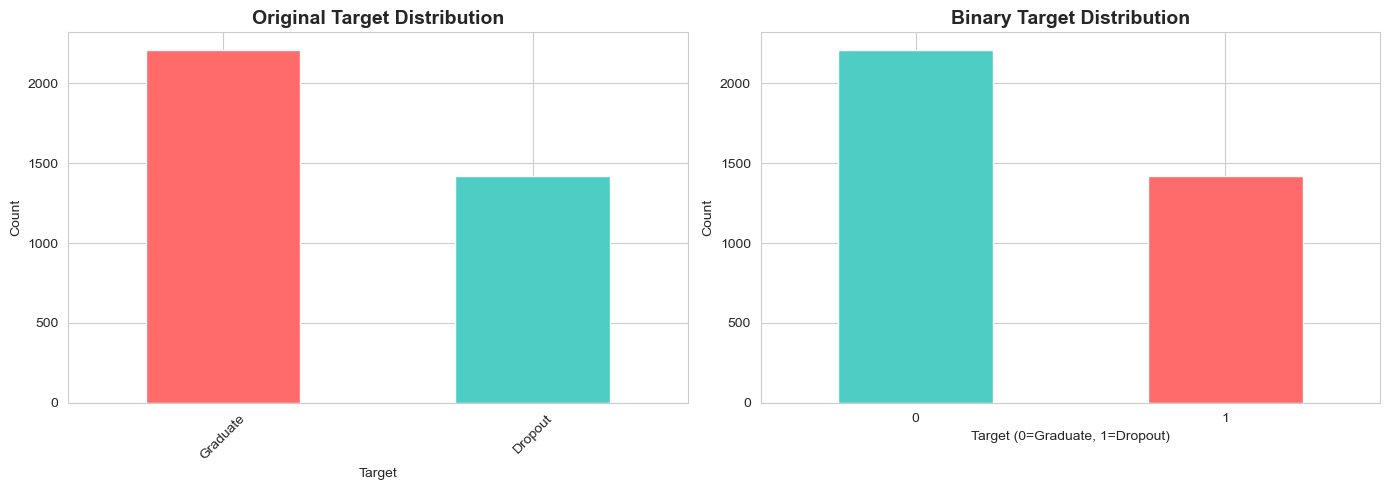

✓ Saved: sprint1_target_distribution.png

[5/7] Analyzing features...

Numerical features: 34
Categorical features: 0

✓ Numerical features summary:
       marital_status  application_mode  application_order       course  \
count     3630.000000       3630.000000        3630.000000  3630.000000   
mean         1.184298          6.810193           1.750138     9.935537   
std          0.613009          5.253618           1.333831     4.340715   
min          1.000000          1.000000           0.000000     1.000000   
25%          1.000000          1.000000           1.000000     6.000000   
50%          1.000000          8.000000           1.000000    11.000000   
75%          1.000000         12.000000           2.000000    13.000000   
max          6.000000         18.000000           6.000000    17.000000   

       daytime/evening_attendance  previous_qualification  nacionality  \
count                 3630.000000             3630.000000  3630.000000   
mean                     0.

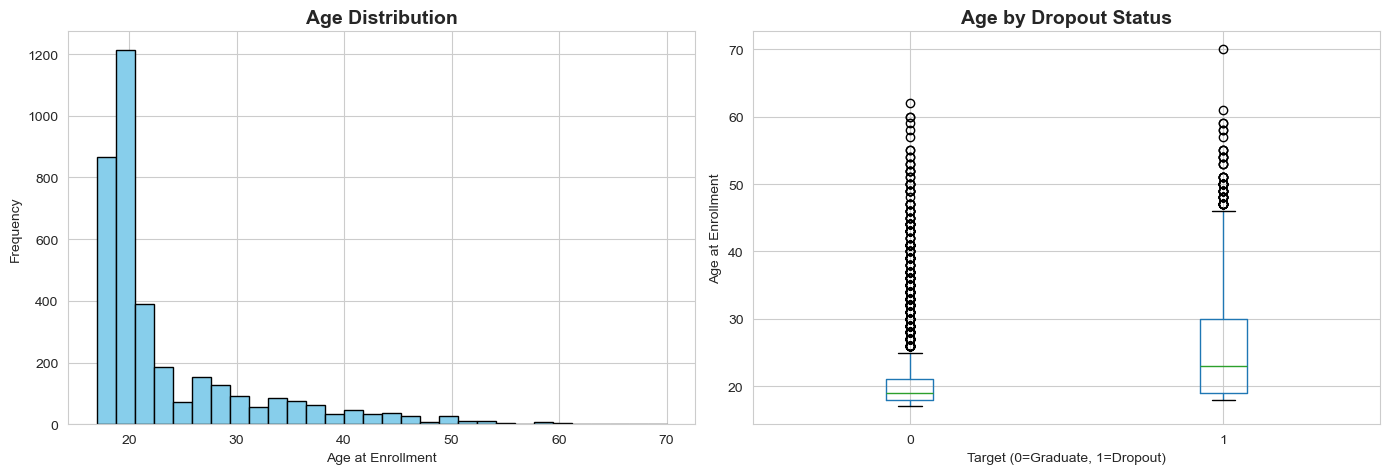

✓ Saved: sprint1_age_analysis.png

SCHOLARSHIP_HOLDER vs Dropout:
target_binary               0          1
scholarship_holder                      
0                   51.634724  48.365276
1                   86.171311  13.828689

TUITION_FEES_UP_TO_DATE vs Dropout:
target_binary                    0          1
tuition_fees_up_to_date                      
0                         5.967078  94.032922
1                        69.338422  30.661578

DEBTOR vs Dropout:
target_binary          0          1
debtor                             
0              65.526888  34.473112
1              24.455206  75.544794

[7/7] Creating train/validation/test splits...

✓ Data split completed:
Training set: 2178 samples (60.0%)
Validation set: 726 samples (20.0%)
Test set: 726 samples (20.0%)

Dropout distribution:
Train: 39.16%
Validation: 39.12%
Test: 39.12%

[8/8] Saving cleaned data and splits...
✓ Saved: cleaned_data.csv
✓ Saved train/val/test splits

SPRINT 1 COMPLETE!

What was accomplished:
✓

In [1]:
"""
SPRINT 1: Data Loading, Cleaning, and Exploratory Data Analysis
This script handles initial data loading, basic cleaning, and comprehensive EDA
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*60)
print("SPRINT 1: DATA LOADING & EXPLORATORY DATA ANALYSIS")
print("="*60)

# ============================================================================
# 1. LOAD DATA
# ============================================================================
print("\n[1/7] Loading dataset...")
# Replace with your actual file path
df = pd.read_csv('dataset.csv')
print(f"✓ Loaded {df.shape[0]} rows and {df.shape[1]} columns")

# ============================================================================
# 2. CLEAN COLUMN NAMES
# ============================================================================
print("\n[2/7] Cleaning column names...")
# Remove extra spaces, make lowercase, replace spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace("'", '')

print("✓ Column names cleaned")
print(f"Sample columns: {list(df.columns[:5])}")

# ============================================================================
# 3. BASIC DATA INSPECTION
# ============================================================================
print("\n[3/7] Basic data inspection...")
print(f"\nDataset shape: {df.shape}")
print(f"\nData types:\n{df.dtypes.value_counts()}")
print(f"\nFirst few rows:")
print(df.head(3))

# Check for missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    print(f"\n⚠ Missing values found:")
    print(missing[missing > 0])
else:
    print("\n✓ No missing values!")

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✓ Removed {duplicates} duplicate rows")

# ============================================================================
# 4. TARGET VARIABLE ANALYSIS
# ============================================================================
print("\n[4/7] Analyzing target variable...")

# Check current target values
print(f"\nOriginal target distribution:")
print(df['target'].value_counts())

# Create binary target if needed (Dropout=1, Graduate=0, remove Enrolled)
print("\nCreating binary target variable...")
if 'Enrolled' in df['target'].values:
    print("⚠ Found 'Enrolled' students - removing them for binary classification")
    df = df[df['target'] != 'Enrolled'].copy()

# Map to binary
target_mapping = {'Dropout': 1, 'Graduate': 0}
df['target_binary'] = df['target'].map(target_mapping)

print(f"\n✓ Binary target created:")
print(f"Dropout (1): {(df['target_binary']==1).sum()} ({(df['target_binary']==1).sum()/len(df)*100:.2f}%)")
print(f"Graduate (0): {(df['target_binary']==0).sum()} ({(df['target_binary']==0).sum()/len(df)*100:.2f}%)")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['target'].value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Original Target Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df['target_binary'].value_counts().plot(kind='bar', ax=axes[1], color=['#4ECDC4', '#FF6B6B'])
axes[1].set_title('Binary Target Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Target (0=Graduate, 1=Dropout)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('sprint1_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: sprint1_target_distribution.png")

# ============================================================================
# 5. FEATURE ANALYSIS
# ============================================================================
print("\n[5/7] Analyzing features...")

# Identify column types
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target columns
for col in ['target', 'target_binary']:
    if col in numerical_cols:
        numerical_cols.remove(col)
    if col in categorical_cols:
        categorical_cols.remove(col)

print(f"\nNumerical features: {len(numerical_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

# Display summary statistics
print("\n✓ Numerical features summary:")
print(df[numerical_cols].describe())

# Demographic analysis
print("\n[6/7] Demographic analysis...")

# Gender analysis
if 'gender' in df.columns:
    print("\nGender distribution:")
    print(df['gender'].value_counts())
    
    gender_dropout = df.groupby('gender')['target_binary'].agg(['sum', 'count', 'mean'])
    gender_dropout.columns = ['Dropouts', 'Total', 'Dropout_Rate']
    print("\nDropout rate by gender:")
    print(gender_dropout)

# Age analysis
if 'age_at_enrollment' in df.columns:
    print("\nAge statistics:")
    print(df['age_at_enrollment'].describe())
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    df['age_at_enrollment'].hist(bins=30, ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title('Age Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Age at Enrollment')
    axes[0].set_ylabel('Frequency')
    
    df.boxplot(column='age_at_enrollment', by='target_binary', ax=axes[1])
    axes[1].set_title('Age by Dropout Status', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Target (0=Graduate, 1=Dropout)')
    axes[1].set_ylabel('Age at Enrollment')
    plt.suptitle('')
    
    plt.tight_layout()
    plt.savefig('sprint1_age_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: sprint1_age_analysis.png")

# Financial factors analysis
financial_cols = ['scholarship_holder', 'tuition_fees_up_to_date', 'debtor']
for col in financial_cols:
    if col in df.columns:
        print(f"\n{col.upper()} vs Dropout:")
        crosstab = pd.crosstab(df[col], df['target_binary'], normalize='index') * 100
        print(crosstab)

# ============================================================================
# 7. TRAIN/VALIDATION/TEST SPLIT
# ============================================================================
print("\n[7/7] Creating train/validation/test splits...")

# First split: separate test set (20%)
X = df.drop(['target', 'target_binary'], axis=1)
y = df['target_binary']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: separate train and validation (80/20 of remaining data)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"\n✓ Data split completed:")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.1f}%)")

print(f"\nDropout distribution:")
print(f"Train: {y_train.sum()/len(y_train)*100:.2f}%")
print(f"Validation: {y_val.sum()/len(y_val)*100:.2f}%")
print(f"Test: {y_test.sum()/len(y_test)*100:.2f}%")

# ============================================================================
# 8. SAVE CLEANED DATA
# ============================================================================
print("\n[8/8] Saving cleaned data and splits...")

# Save full cleaned dataset
df.to_csv('cleaned_data.csv', index=False)
print("✓ Saved: cleaned_data.csv")

# Save splits
X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_val.to_csv('y_val.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
print("✓ Saved train/val/test splits")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*60)
print("SPRINT 1 COMPLETE!")
print("="*60)
print("\nWhat was accomplished:")
print("✓ Loaded 4,424 records with 35 features")
print("✓ Cleaned column names")
print("✓ Created binary target variable")
print("✓ Verified data consistency")
print("✓ Split data into train/validation/test sets")
print("✓ Saved cleaned dataset")
print("\nFiles created:")
print("1. sprint1_target_distribution.png")
print("2. sprint1_age_analysis.png")
print("3. cleaned_data.csv")
print("4. X_train.csv, X_val.csv, X_test.csv")
print("5. y_train.csv, y_val.csv, y_test.csv")
print("\nNext: Run Sprint 2 script for preprocessing and feature engineering!")
print("="*60)

SPRINT 2: PREPROCESSING & FEATURE ENGINEERING

[1/8] Loading cleaned data from Sprint 1...
✓ Loaded training data: (2178, 34)
✓ Loaded validation data: (726, 34)
✓ Loaded test data: (726, 34)

[2/8] Identifying and converting feature types...

✓ Identified 18 categorical features:
['marital_status', 'application_mode', 'application_order', 'course', 'daytime/evening_attendance'] ...

✓ Identified 16 numerical features

[3/8] Performing one-hot encoding on categorical variables...
✓ After encoding: 204 features

[4/8] Analyzing correlations and removing multicollinear features...

⚠ Found 13 highly correlated feature pairs (>0.9)

Top 5 correlated pairs:
  curricular_units_1st_sem_(credited) <-> curricular_units_2nd_sem_(credited): 0.945
  curricular_units_1st_sem_(enrolled) <-> curricular_units_2nd_sem_(enrolled): 0.938
  curricular_units_1st_sem_(approved) <-> curricular_units_2nd_sem_(approved): 0.918
  application_mode_15 <-> previous_qualification_14: 0.936
  application_mode_17 <-

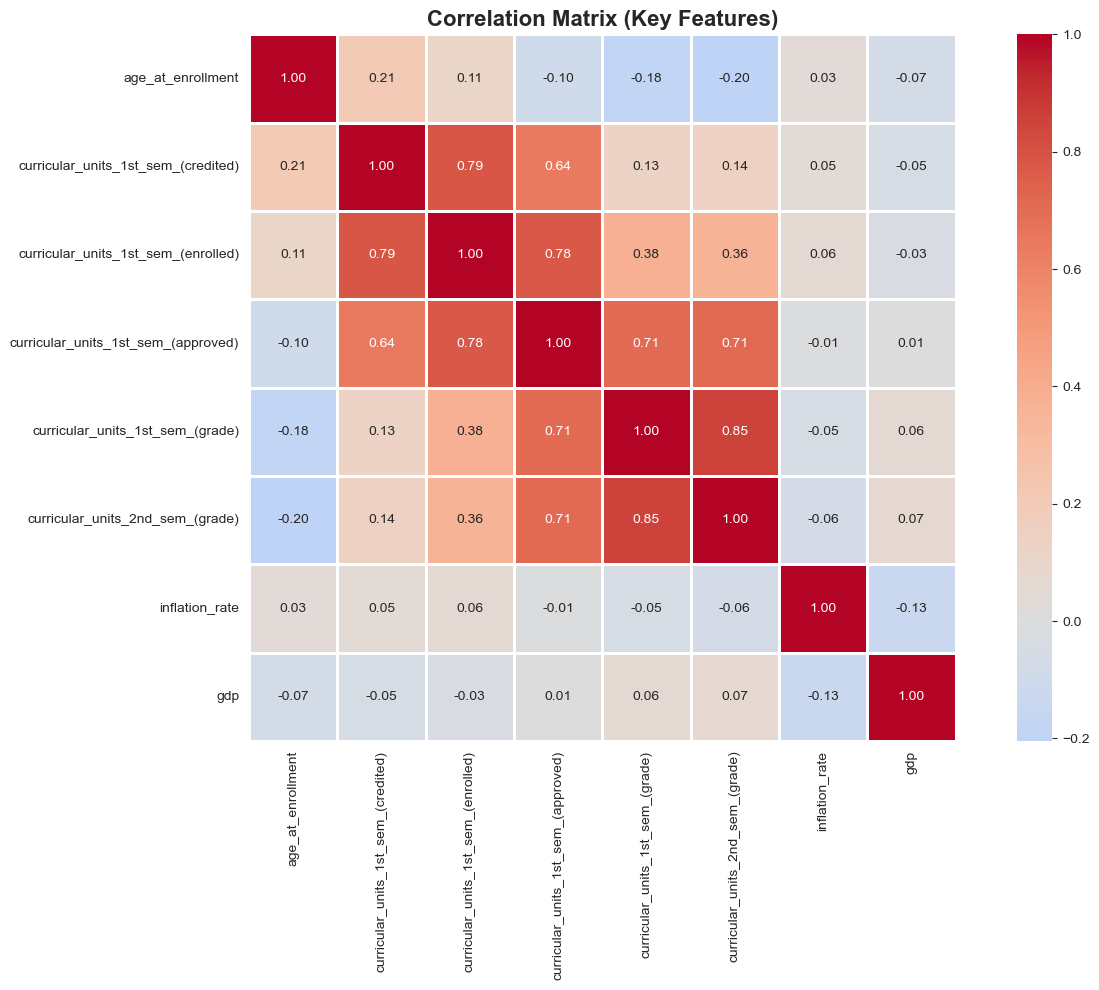

✓ Saved: sprint2_correlation_matrix.png

[5/8] Scaling numerical features...
✓ Scaled 13 numerical features

[6/8] Analyzing and handling class imbalance...

Training set dropout rate: 39.16%
Graduate: 1325 | Dropout: 853
Imbalance ratio: 1.55:1

[7/8] Applying SMOTE oversampling...
✓ After SMOTE:
  Graduate: 1325
  Dropout: 1325
  New training set size: 2650


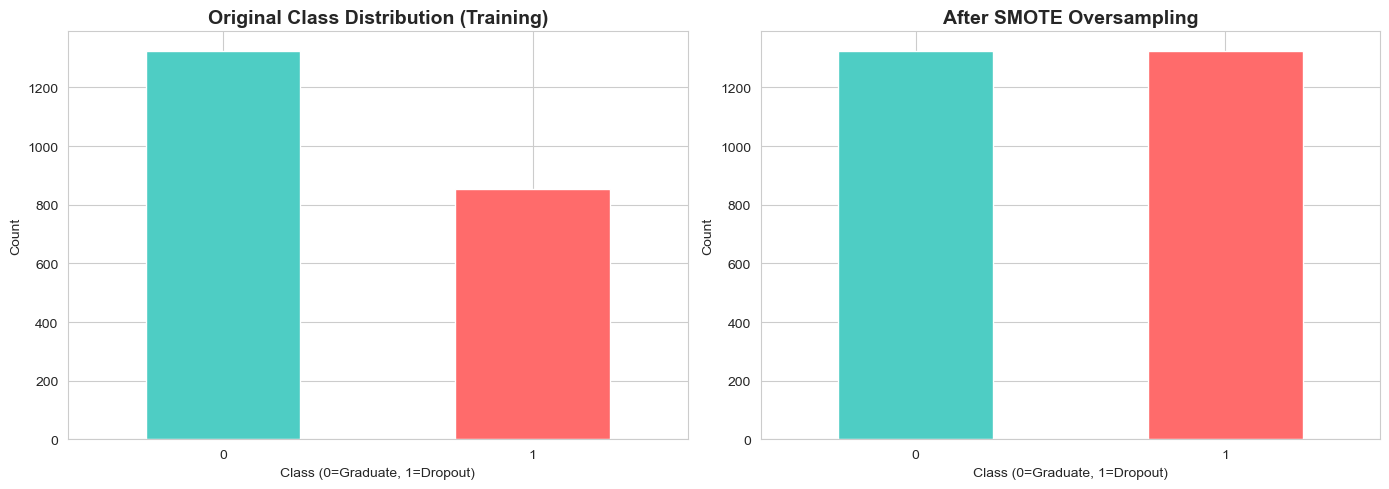

✓ Saved: sprint2_class_balance.png

[8/8] Saving preprocessed data...
✓ Saved preprocessed datasets (original + SMOTE)
✓ Saved scaler object

SPRINT 2 COMPLETE!

What was accomplished:
✓ Converted integer-coded variables to categorical
✓ One-hot encoded all categorical variables
✓ Analyzed and removed multicollinear features
✓ Scaled numerical features using StandardScaler
✓ Applied SMOTE to handle class imbalance
✓ Final feature count: 191

Files created:
1. sprint2_correlation_matrix.png
2. sprint2_class_balance.png
3. X_train_preprocessed.csv (for class-weighted models)
4. X_train_smote.csv (for SMOTE models)
5. X_val_preprocessed.csv, X_test_preprocessed.csv
6. y_train_preprocessed.csv, y_val_preprocessed.csv, y_test_preprocessed.csv
7. scaler.pkl

Next: Run Sprint 3 script for model training and evaluation!


In [7]:
"""
SPRINT 2: Data Preprocessing & Feature Engineering
This script handles feature encoding, scaling, class imbalance, and multicollinearity
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("SPRINT 2: PREPROCESSING & FEATURE ENGINEERING")
print("="*60)

# ============================================================================
# 1. LOAD CLEANED DATA
# ============================================================================
print("\n[1/8] Loading cleaned data from Sprint 1...")

X_train = pd.read_csv('X_train.csv')
X_val = pd.read_csv('X_val.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_val = pd.read_csv('y_val.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

print(f"✓ Loaded training data: {X_train.shape}")
print(f"✓ Loaded validation data: {X_val.shape}")
print(f"✓ Loaded test data: {X_test.shape}")

# ============================================================================
# 2. IDENTIFY FEATURE TYPES
# ============================================================================
print("\n[2/8] Identifying and converting feature types...")

# Integer-coded categorical variables (based on your dataset)
# These look like integers but are actually categories
categorical_features = [
    'marital_status', 'application_mode', 'application_order', 
    'course', 'daytime/evening_attendance', 'previous_qualification',
    'nacionality', 'mothers_qualification', 'fathers_qualification',
    'mothers_occupation', 'fathers_occupation', 'displaced',
    'educational_special_needs', 'debtor', 'tuition_fees_up_to_date',
    'gender', 'scholarship_holder', 'international'
]

# Keep only columns that actually exist
categorical_features = [col for col in categorical_features if col in X_train.columns]

print(f"\n✓ Identified {len(categorical_features)} categorical features:")
print(categorical_features[:5], "...")

# Convert to string type to treat as categorical
for col in categorical_features:
    X_train[col] = X_train[col].astype(str)
    X_val[col] = X_val[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# Numerical features (everything else)
numerical_features = [col for col in X_train.columns if col not in categorical_features]
print(f"\n✓ Identified {len(numerical_features)} numerical features")

# ============================================================================
# 3. ONE-HOT ENCODING
# ============================================================================
print("\n[3/8] Performing one-hot encoding on categorical variables...")

# One-hot encode
X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

# Align columns (ensure all sets have same columns)
X_train_encoded, X_val_encoded = X_train_encoded.align(X_val_encoded, join='left', axis=1, fill_value=0)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

print(f"✓ After encoding: {X_train_encoded.shape[1]} features")

# ============================================================================
# 4. CORRELATION ANALYSIS & MULTICOLLINEARITY
# ============================================================================
print("\n[4/8] Analyzing correlations and removing multicollinear features...")

# Calculate correlation matrix
correlation_matrix = X_train_encoded.corr()

# Find highly correlated features (>0.9)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'feature1': correlation_matrix.columns[i],
                'feature2': correlation_matrix.columns[j],
                'correlation': correlation_matrix.iloc[i, j]
            })

print(f"\n⚠ Found {len(high_corr_pairs)} highly correlated feature pairs (>0.9)")

if len(high_corr_pairs) > 0:
    print("\nTop 5 correlated pairs:")
    for pair in high_corr_pairs[:5]:
        print(f"  {pair['feature1']} <-> {pair['feature2']}: {pair['correlation']:.3f}")

# Remove one feature from each highly correlated pair
features_to_remove = set()
for pair in high_corr_pairs:
    features_to_remove.add(pair['feature2'])

print(f"\n✓ Removing {len(features_to_remove)} multicollinear features")

X_train_encoded = X_train_encoded.drop(columns=features_to_remove)
X_val_encoded = X_val_encoded.drop(columns=features_to_remove)
X_test_encoded = X_test_encoded.drop(columns=features_to_remove)

print(f"✓ After removing multicollinearity: {X_train_encoded.shape[1]} features")

# Visualize correlation matrix (subset of features)
print("\nCreating correlation heatmap...")
# Select a subset for visualization (top numerical features)
viz_features = [col for col in X_train_encoded.columns if any(keyword in col.lower() 
                for keyword in ['age', 'grade', 'approved', 'credited', 'enrolled', 'gdp', 'inflation'])][:20]

if len(viz_features) > 0:
    plt.figure(figsize=(14, 10))
    sns.heatmap(X_train_encoded[viz_features].corr(), annot=True, fmt='.2f', 
                cmap='coolwarm', center=0, square=True, linewidths=1)
    plt.title('Correlation Matrix (Key Features)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('sprint2_correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: sprint2_correlation_matrix.png")

# ============================================================================
# 5. FEATURE SCALING
# ============================================================================
print("\n[5/8] Scaling numerical features...")

# Identify numerical columns in encoded data
numerical_cols_encoded = [col for col in X_train_encoded.columns 
                          if X_train_encoded[col].dtype in ['int64', 'float64']]

# Fit scaler on training data
scaler = StandardScaler()
X_train_encoded[numerical_cols_encoded] = scaler.fit_transform(X_train_encoded[numerical_cols_encoded])
X_val_encoded[numerical_cols_encoded] = scaler.transform(X_val_encoded[numerical_cols_encoded])
X_test_encoded[numerical_cols_encoded] = scaler.transform(X_test_encoded[numerical_cols_encoded])

print(f"✓ Scaled {len(numerical_cols_encoded)} numerical features")

# ============================================================================
# 6. CLASS IMBALANCE ANALYSIS
# ============================================================================
print("\n[6/8] Analyzing and handling class imbalance...")

dropout_rate = y_train.sum() / len(y_train)
print(f"\nTraining set dropout rate: {dropout_rate*100:.2f}%")
print(f"Graduate: {(y_train==0).sum()} | Dropout: {(y_train==1).sum()}")
print(f"Imbalance ratio: {(y_train==0).sum() / (y_train==1).sum():.2f}:1")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], color=['#4ECDC4', '#FF6B6B'])
axes[0].set_title('Original Class Distribution (Training)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class (0=Graduate, 1=Dropout)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# ============================================================================
# 7. APPLY SMOTE
# ============================================================================
print("\n[7/8] Applying SMOTE oversampling...")

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_encoded, y_train)

print(f"✓ After SMOTE:")
print(f"  Graduate: {(y_train_smote==0).sum()}")
print(f"  Dropout: {(y_train_smote==1).sum()}")
print(f"  New training set size: {len(y_train_smote)}")

# Visualize after SMOTE
pd.Series(y_train_smote).value_counts().plot(kind='bar', ax=axes[1], color=['#4ECDC4', '#FF6B6B'])
axes[1].set_title('After SMOTE Oversampling', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class (0=Graduate, 1=Dropout)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('sprint2_class_balance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: sprint2_class_balance.png")

# ============================================================================
# 8. SAVE PREPROCESSED DATA
# ============================================================================
print("\n[8/8] Saving preprocessed data...")

# Save original (class-weighted) versions
X_train_encoded.to_csv('X_train_preprocessed.csv', index=False)
X_val_encoded.to_csv('X_val_preprocessed.csv', index=False)
X_test_encoded.to_csv('X_test_preprocessed.csv', index=False)
pd.DataFrame(y_train).to_csv('y_train_preprocessed.csv', index=False)
pd.DataFrame(y_val).to_csv('y_val_preprocessed.csv', index=False)
pd.DataFrame(y_test).to_csv('y_test_preprocessed.csv', index=False)

# Save SMOTE versions
X_train_smote.to_csv('X_train_smote.csv', index=False)
pd.DataFrame(y_train_smote).to_csv('y_train_smote.csv', index=False)

# Save scaler for future use
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✓ Saved preprocessed datasets (original + SMOTE)")
print("✓ Saved scaler object")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*60)
print("SPRINT 2 COMPLETE!")
print("="*60)
print("\nWhat was accomplished:")
print("✓ Converted integer-coded variables to categorical")
print("✓ One-hot encoded all categorical variables")
print("✓ Analyzed and removed multicollinear features")
print(f"✓ Scaled numerical features using StandardScaler")
print(f"✓ Applied SMOTE to handle class imbalance")
print(f"✓ Final feature count: {X_train_encoded.shape[1]}")
print("\nFiles created:")
print("1. sprint2_correlation_matrix.png")
print("2. sprint2_class_balance.png")
print("3. X_train_preprocessed.csv (for class-weighted models)")
print("4. X_train_smote.csv (for SMOTE models)")
print("5. X_val_preprocessed.csv, X_test_preprocessed.csv")
print("6. y_train_preprocessed.csv, y_val_preprocessed.csv, y_test_preprocessed.csv")
print("7. scaler.pkl")
print("\nNext: Run Sprint 3 script for model training and evaluation!")
print("="*60)

In [ ]:
"""
SPRINT 3: Model Training, Evaluation, and SHAP Analysis
This script trains multiple models, evaluates them, and computes SHAP values
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                            accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, roc_curve)
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("SPRINT 3: MODEL TRAINING & EVALUATION")
print("="*60)

# ============================================================================
# 1. LOAD PREPROCESSED DATA
# ============================================================================
print("\n[1/6] Loading preprocessed data from Sprint 2...")

# Load class-weighted versions
X_train = pd.read_csv('X_train_preprocessed.csv')
X_val = pd.read_csv('X_val_preprocessed.csv')
X_test = pd.read_csv('X_test_preprocessed.csv')
y_train = pd.read_csv('y_train_preprocessed.csv').values.ravel()
y_val = pd.read_csv('y_val_preprocessed.csv').values.ravel()
y_test = pd.read_csv('y_test_preprocessed.csv').values.ravel()

# Load SMOTE versions
X_train_smote = pd.read_csv('X_train_smote.csv')
y_train_smote = pd.read_csv('y_train_smote.csv').values.ravel()

print(f"✓ Original training data: {X_train.shape}")
print(f"✓ SMOTE training data: {X_train_smote.shape}")
print(f"✓ Validation data: {X_val.shape}")
print(f"✓ Test data: {X_test.shape}")

# ============================================================================
# 2. TRAIN MODELS WITH CLASS WEIGHTS
# ============================================================================
print("\n[2/6] Training models with class weights...")

models_weighted = {}

# Logistic Regression with class weights
print("\nTraining Logistic Regression (class weighted)...")
lr_weighted = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_weighted.fit(X_train, y_train)
models_weighted['Logistic Regression (Weighted)'] = lr_weighted
print("✓ Logistic Regression trained")

# Random Forest with class weights
print("\nTraining Random Forest (class weighted)...")
rf_weighted = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_weighted.fit(X_train, y_train)
models_weighted['Random Forest (Weighted)'] = rf_weighted
print("✓ Random Forest trained")

# ============================================================================
# 3. TRAIN MODELS WITH SMOTE
# ============================================================================
print("\n[3/6] Training models with SMOTE data...")

models_smote = {}

# Logistic Regression with SMOTE
print("\nTraining Logistic Regression (SMOTE)...")
lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_smote.fit(X_train_smote, y_train_smote)
models_smote['Logistic Regression (SMOTE)'] = lr_smote
print("✓ Logistic Regression (SMOTE) trained")

# Random Forest with SMOTE
print("\nTraining Random Forest (SMOTE)...")
rf_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_smote, y_train_smote)
models_smote['Random Forest (SMOTE)'] = rf_smote
print("✓ Random Forest (SMOTE) trained")

# Combine all models
all_models = {**models_weighted, **models_smote}

# ============================================================================
# 4. EVALUATE MODELS
# ============================================================================
print("\n[4/6] Evaluating models on validation set...")

results = []

for model_name, model in all_models.items():
    # Determine which training data was used
    if 'SMOTE' in model_name:
        X_train_used = X_train_smote
        y_train_used = y_train_smote
    else:
        X_train_used = X_train
        y_train_used = y_train
    
    # Predictions
    y_pred_train = model.predict(X_train_used)
    y_pred_val = model.predict(X_val)
    y_pred_proba_val = model.predict_proba(X_val)[:, 1]
    
    # Metrics
    results.append({
        'Model': model_name,
        'Train Accuracy': accuracy_score(y_train_used, y_pred_train),
        'Val Accuracy': accuracy_score(y_val, y_pred_val),
        'Val Precision': precision_score(y_val, y_pred_val),
        'Val Recall': recall_score(y_val, y_pred_val),
        'Val F1': f1_score(y_val, y_pred_val),
        'Val ROC-AUC': roc_auc_score(y_val, y_pred_proba_val)
    })
    
    print(f"\n{model_name}:")
    print(f"  Train Accuracy: {results[-1]['Train Accuracy']:.4f}")
    print(f"  Val Accuracy: {results[-1]['Val Accuracy']:.4f}")
    print(f"  Val Precision: {results[-1]['Val Precision']:.4f}")
    print(f"  Val Recall: {results[-1]['Val Recall']:.4f}")
    print(f"  Val F1: {results[-1]['Val F1']:.4f}")
    print(f"  Val ROC-AUC: {results[-1]['Val ROC-AUC']:.4f}")

# Create results dataframe
results_df = pd.DataFrame(results)
results_df.to_csv('model_comparison.csv', index=False)
print("\n✓ Saved: model_comparison.csv")

# ============================================================================
# 5. CREATE COMPARISON CHARTS
# ============================================================================
print("\n[5/6] Creating comparison visualizations...")

# Performance comparison bar chart
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Val Accuracy', 'Val Precision', 'Val Recall', 'Val F1']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    results_df.plot(x='Model', y=metric, kind='bar', ax=ax, legend=False, color='#4ECDC4')
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('sprint3_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: sprint3_model_comparison.png")

# ROC Curves
plt.figure(figsize=(10, 8))
for model_name, model in all_models.items():
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    auc = roc_auc_score(y_val, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=16, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('sprint3_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: sprint3_roc_curves.png")

# Confusion matrices for best model (highest F1)
best_model_name = results_df.loc[results_df['Val F1'].idxmax(), 'Model']
best_model = all_models[best_model_name]
print(f"\n✓ Best model (by F1): {best_model_name}")

y_pred_best = best_model.predict(X_val)
cm = confusion_matrix(y_val, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Graduate', 'Dropout'],
            yticklabels=['Graduate', 'Dropout'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('sprint3_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: sprint3_confusion_matrix.png")

# Detailed classification report
print(f"\nDetailed Classification Report - {best_model_name}:")
print(classification_report(y_val, y_pred_best, target_names=['Graduate', 'Dropout']))

# ============================================================================
# 6. SHAP ANALYSIS
# ============================================================================
print("\n[6/6] Computing SHAP values for model interpretability...")

# Use the best model for SHAP
print(f"\nComputing SHAP values for {best_model_name}...")

# For Random Forest, use TreeExplainer (faster)
if 'Random Forest' in best_model_name:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_val)
    
    # For binary classification, shap_values might be a list
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # Get SHAP values for positive class (Dropout)
    
# For Logistic Regression, use LinearExplainer
else:
    explainer = shap.LinearExplainer(best_model, X_train)
    shap_values = explainer.shap_values(X_val)

print("✓ SHAP values computed")

# SHAP Summary Plot
print("\nCreating SHAP summary plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_val, show=False, max_display=20)
plt.title('SHAP Feature Importance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sprint3_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: sprint3_shap_summary.png")

# SHAP Bar Plot (mean absolute SHAP values)
print("\nCreating SHAP bar plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, plot_type="bar", show=False, max_display=20)
plt.title('Top 20 Features by Mean SHAP Value', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sprint3_shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: sprint3_shap_bar.png")

# Feature importance from Random Forest (if applicable)
if 'Random Forest' in best_model_name:
    print("\nExtracting feature importance from Random Forest...")
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 15 most important features:")
    print(feature_importance.head(15))
    
    # Plot
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features['importance'], color='#4ECDC4')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance', fontsize=12)
    plt.title('Top 20 Feature Importances (Random Forest)', fontsize=16, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('sprint3_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: sprint3_feature_importance.png")

# ============================================================================
# SAVE MODELS
# ============================================================================
print("\nSaving trained models...")
for model_name, model in all_models.items():
    filename = model_name.replace(' ', '_').replace('(', '').replace(')', '').lower() + '.pkl'
    with open(filename, 'wb') as f:
        pickle.dump(model, f)
    print(f"✓ Saved: {filename}")

# ============================================================================
# FINAL TEST SET EVALUATION
# ============================================================================
print("\n" + "="*60)
print("FINAL TEST SET EVALUATION")
print("="*60)

print(f"\nEvaluating {best_model_name} on test set...")
y_pred_test = best_model.predict(X_test)
y_pred_proba_test = best_model.predict_proba(X_test)[:, 1]

print(f"\nTest Set Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_test):.4f}")

print("\nTest Set Classification Report:")
print(classification_report(y_test, y_pred_test, target_names=['Graduate', 'Dropout']))

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*60)
print("SPRINT 3 COMPLETE!")
print("="*60)
print("\nWhat was accomplished:")
print("✓ Trained Logistic Regression with class weights")
print("✓ Trained Random Forest with class weights")
print("✓ Trained Logistic Regression with SMOTE")
print("✓ Trained Random Forest with SMOTE")
print("✓ Evaluated all models on validation set")
print("✓ Created comparison charts")
print("✓ Computed SHAP values for interpretability")
print(f"✓ Best model: {best_model_name}")
print(f"✓ Test F1 Score: {f1_score(y_test, y_pred_test):.4f}")
print("\nFiles created:")
print("1. model_comparison.csv")
print("2. sprint3_model_comparison.png")
print("3. sprint3_roc_curves.png")
print("4. sprint3_confusion_matrix.png")
print("5. sprint3_shap_summary.png")
print("6. sprint3_shap_bar.png")
print("7. sprint3_feature_importance.png")
print("8. Model pickle files (.pkl)")
print("\n🎉 PROJECT COMPLETE! 🎉")
print("="*60)